In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import catppuccin
import sys
sys.path.append("../src")
from utils import set_theme_and_plot_params

FINAL_METRICS_DF_PATH = Path("../data/processed/final_metrics_df.csv")
RAND_FOR_CV_RESULTS_PATH = Path("../data/processed/random_forest_gridsearch_cv_results.csv")
final_metrics_df = pd.read_csv(FINAL_METRICS_DF_PATH, index_col=0)
rand_for_cv_results_df = pd.read_csv(RAND_FOR_CV_RESULTS_PATH)

In [2]:
# look at the final metrics df
final_metrics_df.head()

,CV Mean R²,CV Std,Test R² score,MAE,MSE,MAPE
Model,,,,,,
Dummy,-0.00,0.00,-0.01,2835.03,14652929.75,3.561752e+18
Linear Regression,0.88,0.04,0.88,911.06,1711603.37,3.087822e+17
Random Forest,0.98,0.01,0.98,333.57,283982.16,5.000000e-02
XG Boost,0.98,0.00,0.98,363.49,289623.44,8.561718e+16
Random Forest (Tuned),0.98,0.01,0.98,333.34,284023.79,5.000000e-02


In [3]:
# set theme and plot params
set_theme_and_plot_params()

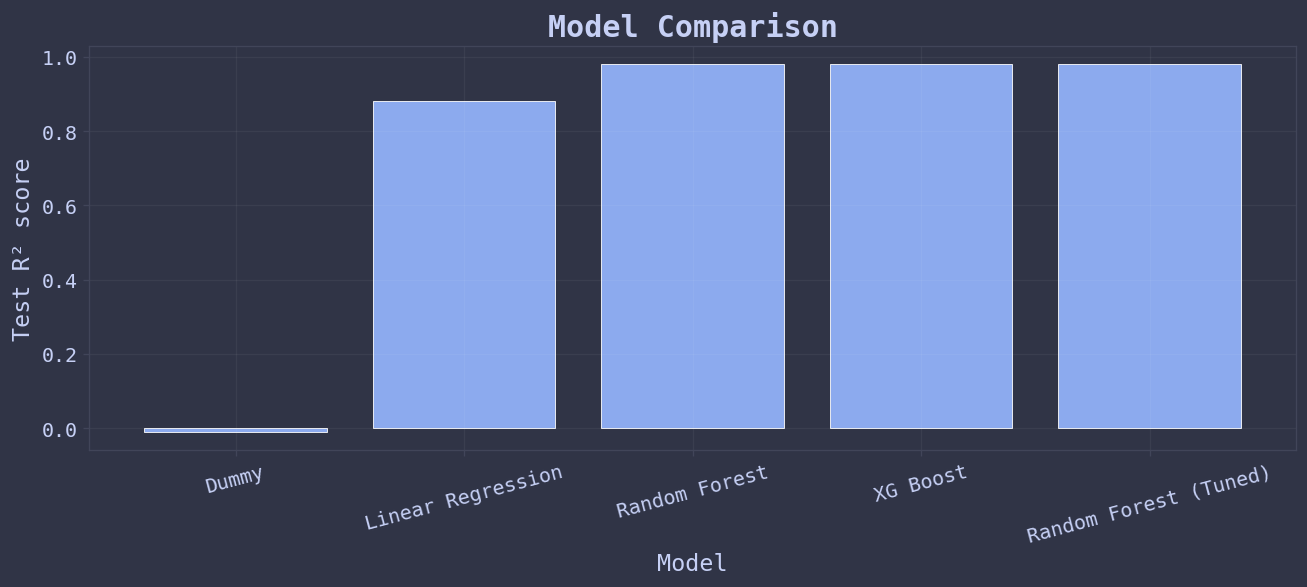

In [ ]:
# plot Test R² score

plt.figure(figsize=(11, 5))
plt.bar(final_metrics_df.index, final_metrics_df["Test R² score"], color=catppuccin.PALETTE.frappe.colors.blue.hex, edgecolor="white", linewidth=0.5)
plt.xlabel("Model")
plt.ylabel("Test R² score")
plt.xticks(rotation=15)
plt.title("Model Comparison")
plt.grid(alpha=0.05, color="white")
plt.tight_layout()
plt.show()

In [5]:
# look at the cv results
rand_for_cv_results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__max_depth,param_regressor__min_samples_leaf,param_regressor__min_samples_split,param_regressor__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,44.461275,21.175968,0.797128,0.080846,NaN,1,2,100,"{'regressor__max_depth': None, 'regressor__min...",0.967357,0.980751,0.979309,0.979224,0.985747,0.978478,0.006049,3
1,171.236820,104.143109,20.288004,23.021604,NaN,1,2,300,"{'regressor__max_depth': None, 'regressor__min...",0.967795,0.980923,0.979475,0.979384,0.985880,0.978692,0.005941,1
2,42.951889,28.277276,0.668386,0.079288,NaN,1,5,100,"{'regressor__max_depth': None, 'regressor__min...",0.967229,0.980652,0.979072,0.979402,0.985734,0.978418,0.006085,4
3,231.441417,188.206649,3.967243,2.147438,NaN,1,5,300,"{'regressor__max_depth': None, 'regressor__min...",0.967632,0.980818,0.979251,0.979522,0.985845,0.978614,0.005983,2
4,100.402781,57.381407,1.878752,0.322079,NaN,2,2,100,"{'regressor__max_depth': None, 'regressor__min...",0.966561,0.980156,0.978579,0.979050,0.985418,0.977953,0.006196,7


In [6]:
# what are the best parameters based on mean test score?
best = rand_for_cv_results_df.sort_values("mean_test_score", ascending=False).head(10)

best[[
    "param_regressor__n_estimators",
    "param_regressor__max_depth",
    "param_regressor__min_samples_leaf",
    "param_regressor__min_samples_split",
    "mean_test_score"
]]

,param_regressor__n_estimators,param_regressor__max_depth,param_regressor__min_samples_leaf,param_regressor__min_samples_split,mean_test_score
1,300,NaN,1,2,0.978692
3,300,NaN,1,5,0.978614
0,100,NaN,1,2,0.978478
2,100,NaN,1,5,0.978418
5,300,NaN,2,2,0.978144
7,300,NaN,2,5,0.978110
4,100,NaN,2,2,0.977953
6,100,NaN,2,5,0.977927
17,300,20.0,1,2,0.977278
19,300,20.0,1,5,0.977203


In [7]:
# which one is the best model?
best_model = rand_for_cv_results_df.sort_values("rank_test_score").iloc[0]
best_model[["params", "mean_test_score", "std_test_score"]]

params             {'regressor__max_depth': None, 'regressor__min...
mean_test_score                                             0.978692
std_test_score                                              0.005941
Name: 1, dtype: object

# Machine Learning Conclusions

Four machine learning models were trained to predict store sales.

• A Dummy Regressor was used as a baseline by predicting the median sales value. As expected, it performed poorly, achieving a test R² score of -0.01 and the highest mean absolute error among all models. 

• Multiple Linear Regression demonstrated strong overall performance, achieving a test R² score of 0.88. This suggests that a substantial proportion of the variation in sales can be explained through linear relationships between the features and the target. However, the extremely high Mean Absolute Percentage Error (MAPE) is misleading because some observations have zero sales, causing the metric to become unstable. 

• Random Forest and XGBoost were the best-performing models, both achieving a test R² score of 0.98. Their superior performance suggests that the data contains nonlinear relationships that tree-based ensemble methods capture more effectively than a linear model. Among the two, Random Forest achieved the lowest Mean Absolute Error (≈€334), meaning that its predictions differed from the actual sales by approximately €334 on average. 

• GridSearchCV identified the best Random Forest configuration as 300 trees, unlimited maximum depth, a minimum of one sample per leaf and two samples required to split a node. This configuration achieved a mean cross-validation R² score of approximately 0.979. Although it produced the best overall performance, the improvement over the default Random Forest model was marginal, indicating that the default hyperparameters were already well suited for this dataset.
Overall, tree-based ensemble methods proved to be the most suitable approach for this sales forecasting task, producing highly accurate predictions while requiring only modest hyperparameter tuning.